# Edit Propagated Masks

This notebook is meant for editing masks that have already been auto generated from the SAM2 model. It includes a widget that allows you to flip through the frames of the video and edit the masks using a drawing tool. Once the masks for each of the frames are looking good, the masks are saved to a json file. For information about how the widget works and the guidelines for how to label the data consitently, see the Installation_and_Mask_Editing_Instructions.pdf.

The first thing you will need to do is import the functions needed to create the MaskEditor widget from the labelling_functions.py file. Make sure that this notebook and the labelling_functions.py file are in the same directory. Run the cell below to import the functions.

In [9]:
from matplotlib import pyplot as plt
from labelling_functions import MaskEditor, select_video_to_edit

Now we need to choose which video we want edit the masks for. Since the data within each video folder is stored in a standard format, all you need to do is input the path to the folder that contains the annotations and images of the video as the `video_folder`. If you have not started editing the chosen video, then it will create a new file inside the annotations folder call "edited_instances_default.json" which is a copy of the autogenerated masks from "instance_default.json". All of the edits you make to the masks will be saved in this new json file instead of overwritting the original. If you have already started editing the chosen video then it will select that file to continue editing on instead of creating new one. 

In [5]:
# Select which video to edit the masks for by inputting the video folder
images_dir, edited_annotations_path = select_video_to_edit(video_folder = "/home/simone/shared-data/labeled/simone/Ganaraska__Ganaraska 2024__10012024-10072024__24  10  01  11  32__2019")

Running the cell below will create the widget. You can choose which frame you want to start on by changing the `start_frame` argument so that you don't have to flip through a bunch of empty images. You can save the edited masks at any point by clicking the Save JSON button. Please note that the masks are not saved automatically so if you rerun the cell below after editing some masks then your edits will be lost.

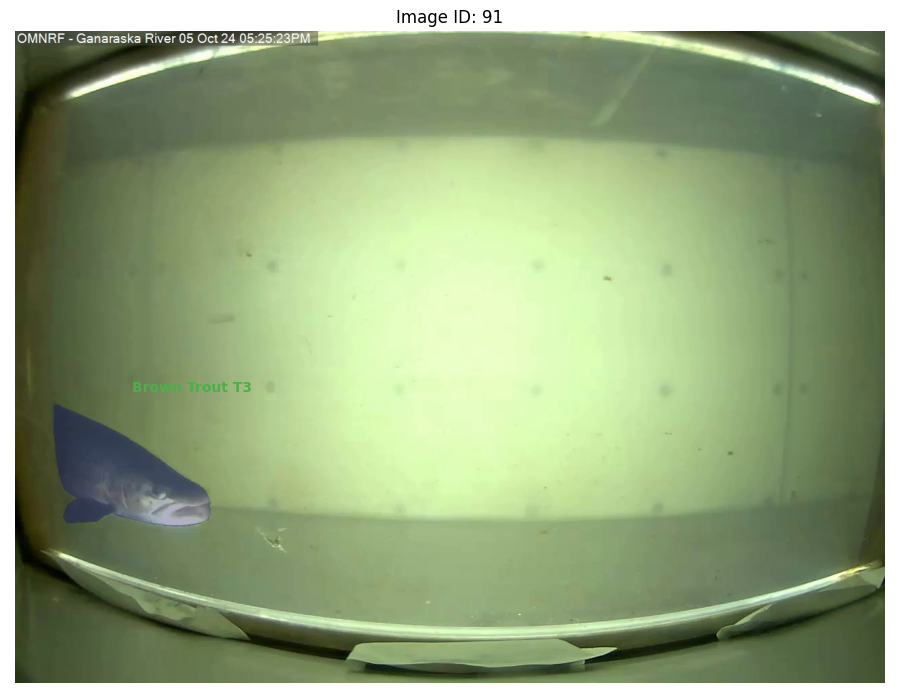

In [10]:
%matplotlib widget

# Clean up any existing widget to save memory
if 'widget' in locals():
    plt.close(widget.fig)
    del widget

plt.close('all')

widget = MaskEditor(coco_json_path=edited_annotations_path, 
                    frames_dir=images_dir, 
                    start_frame=90,
                    mask_transparancy=0.3)